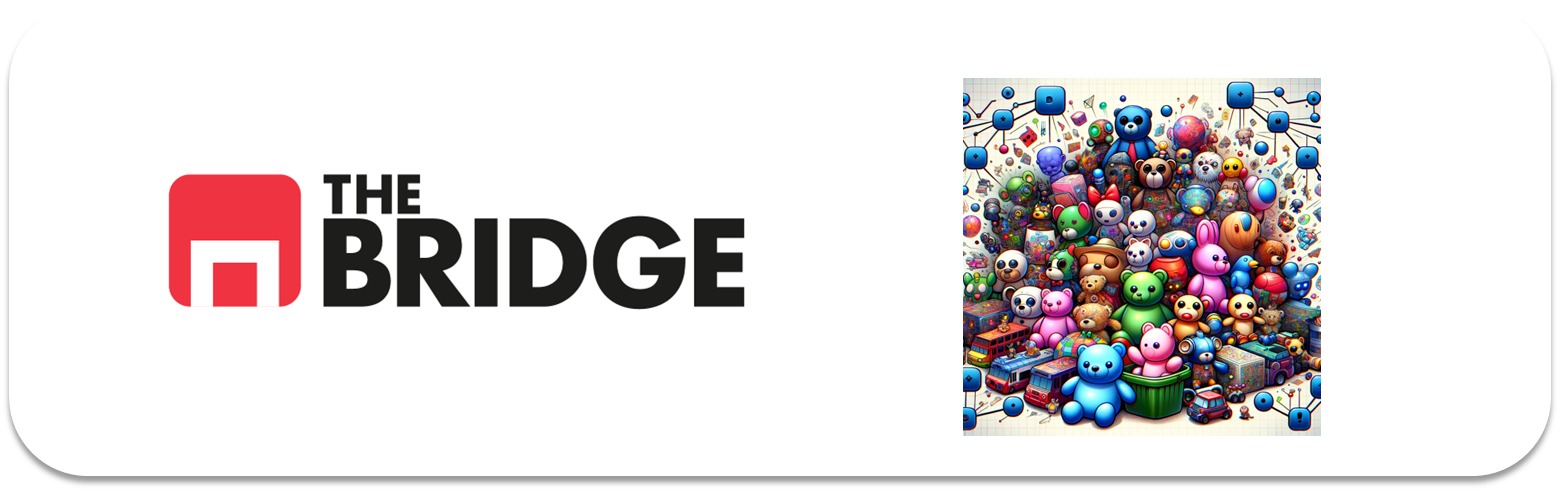

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes en escala de grises de 64 × 64 píxeles de rostros.   


Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una feature y por cada imagen hay $64\times 64 = 4096$ features.  

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en el dataset.  

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en cada imagen, pero nosotros lo vamos a hacer de forma no supervisada. 



### #1.1


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [2]:
# 1. Cargar el conjunto de datos
# Esta función descargará los datos si no los tienes en caché y los cargará en memoria.
# El resultado se almacena en una variable que actúa como un diccionario (objeto Bunch).
print("Cargando el dataset Olivetti Faces...")
olivetti = fetch_olivetti_faces()

# 2. Mostrar la descripción del dataset
# Accedemos a la clave 'DESCR' del objeto para leer la documentación adjunta.
print("\n--- DESCRIPCIÓN DEL DATASET ---\n")
print(olivetti.DESCR)

Cargando el dataset Olivetti Faces...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\Usuario\scikit_learn_data

--- DESCRIPCIÓN DEL DATASET ---

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background w

### #1.2 

Aunque no lo vas a usar hasta el final de la práctica, muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [4]:
# 1. Mostrar el target (las etiquetas)
print("--- TARGET (Identidad de la persona) ---")
print(olivetti.target)
# Verás que va del 0 al 39 (40 personas), repetido 10 veces cada uno secuencialmente.

# 2. Cargar todo en un DataFrame
# Creamos el DataFrame con los datos de las imágenes (las 4096 features)
df = pd.DataFrame(olivetti.data)

# Añadimos la columna 'target' al final
df['target'] = olivetti.target

print("\n--- DATAFRAME ORIGINAL (Primeras 5 filas) ---")
print(df.head())

# 3. Reordenar aleatoriamente (Shuffle)
# Usamos sample con frac=1 para coger el 100% de los datos, pero desordenados.
# El random_state=42 es una buena práctica para que, si lo repites, salga el mismo desorden.
df_shuffled = df.sample(frac=1, random_state=42)

print("\n--- DATAFRAME REORDENADO ALEATORIAMENTE ---")
print(df_shuffled.head())

--- TARGET (Identidad de la persona) ---
[ 0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  2  2  2  2
  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4
  4  4  5  5  5  5  5  5  5  5  5  5  6  6  6  6  6  6  6  6  6  6  7  7
  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8  8  8  9  9  9  9  9  9
  9  9  9  9 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11
 12 12 12 12 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 14 14 14 14
 14 14 14 14 14 14 15 15 15 15 15 15 15 15 15 15 16 16 16 16 16 16 16 16
 16 16 17 17 17 17 17 17 17 17 17 17 18 18 18 18 18 18 18 18 18 18 19 19
 19 19 19 19 19 19 19 19 20 20 20 20 20 20 20 20 20 20 21 21 21 21 21 21
 21 21 21 21 22 22 22 22 22 22 22 22 22 22 23 23 23 23 23 23 23 23 23 23
 24 24 24 24 24 24 24 24 24 24 25 25 25 25 25 25 25 25 25 25 26 26 26 26
 26 26 26 26 26 26 27 27 27 27 27 27 27 27 27 27 28 28 28 28 28 28 28 28
 28 28 29 29 29 29 29 29 29 29 29 29 30 30 30 30 30 30 30 30 30 30 31 31
 31 31 31 

### #1.3

Vamos a dividir en train y test, pero OJO RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es uan práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (80-10-10). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 90-10 y luego otro split 89-11 sobre el de 80 (para que de los números aproximados), por ejemplo.

In [7]:
# Separamos las features (X) del target (y) dentro de nuestro dataframe barajado
X = df_shuffled.drop("target", axis=1)
y = df_shuffled["target"]

# --- PASO 1: Separar Entrenamiento (80%) del resto (20%) ---
# El 'resto' contendrá Validación + Test temporalmente
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y,
    test_size=0.20,       # 20% se va al grupo 'resto'
    stratify=y,           # ¡Importante! Mantiene la proporción de caras
    random_state=42
)

# --- PASO 2: Separar Validación (10%) y Test (10%) ---
# Como X_rest es el 20% del total, si lo partimos por la mitad (0.5),
# obtenemos dos grupos del 10% del total original cada uno.
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest,
    test_size=0.50,       # 50% del 'resto' (que equivale al 10% global)
    stratify=y_rest,      # Estratificamos de nuevo sobre el subconjunto
    random_state=42
)

# Verificamos las dimensiones para asegurar que el 80-10-10 es correcto
print(f"Dimensiones Train: {X_train.shape} (Debe ser 320 imágenes)")
print(f"Dimensiones Val:   {X_val.shape}   (Debe ser 40 imágenes)")
print(f"Dimensiones Test:  {X_test.shape}  (Debe ser 40 imágenes)")

# Comprobación rápida de estratificación (opcional)
# Vemos cuántas fotos hay de la persona '0' en el set de validación (debería haber 1, ya que son 10 en total y 10% va a val)
print(f"\nEjemplo estratificación: Fotos de la persona 0 en Validación: {sum(y_val == 0)}")

Dimensiones Train: (320, 4096) (Debe ser 320 imágenes)
Dimensiones Val:   (40, 4096)   (Debe ser 40 imágenes)
Dimensiones Test:  (40, 4096)  (Debe ser 40 imágenes)

Ejemplo estratificación: Fotos de la persona 0 en Validación: 1


### #1.4

Crea los pares X,y para train, validation y test.

--- Verificación de los Pares (Shapes) ---
Train Set -> X: (320, 4096), y: (320,)
Val Set   -> X: (40, 4096),   y: (40,)
Test Set  -> X: (40, 4096),  y: (40,)

Visualizando la primera muestra del set de entrenamiento...
Persona ID: 13


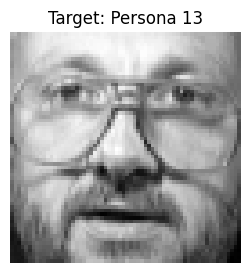

In [9]:
# 1. Verificación de dimensiones (Shapes)
# Confirmamos que tenemos las 4096 columnas de píxeles y el número correcto de filas.
print("--- Verificación de los Pares (Shapes) ---")
print(f"Train Set -> X: {X_train.shape}, y: {y_train.shape}")
print(f"Val Set   -> X: {X_val.shape},   y: {y_val.shape}")
print(f"Test Set  -> X: {X_test.shape},  y: {y_test.shape}")

# 2. Visualización de seguridad (Sanity Check)
# Es vital comprobar que al dividir no hemos "roto" la imagen.
# Tomamos la primera muestra de X_train, la reformamos a 64x64 y la mostramos.

# Recuperamos la primera imagen (fila 0) y su etiqueta
sample_image = X_train.iloc[0].values.reshape(64, 64)
sample_label = y_train.iloc[0]

print(f"\nVisualizando la primera muestra del set de entrenamiento...")
print(f"Persona ID: {sample_label}")

plt.figure(figsize=(3, 3))
plt.imshow(sample_image, cmap='gray')
plt.title(f"Target: Persona {sample_label}")
plt.axis('off')
plt.show()

Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

--- Visualizando muestra del Set de Entrenamiento ---


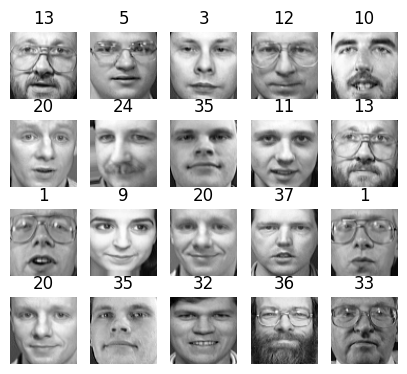

In [11]:
# 1. Definimos la función de visualización
def plot_faces(faces, labels, n_cols=5):
    # NOTA EXPERTA: Añadimos esta comprobación por seguridad.
    # Si 'faces' es un DataFrame de Pandas, extraemos sus valores numpy (.values)
    # porque la función .reshape() es nativa de Numpy, no de Pandas.
    if hasattr(faces, 'values'):
        faces = faces.values
    if hasattr(labels, 'values'):
        labels = labels.values

    # Reconstruimos la imagen de 1 fila de 4096 pixeles a una matriz 64x64
    faces = faces.reshape(-1, 64, 64)
    
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

# 2. Usamos iloc para seleccionar un subconjunto
# Seleccionamos las primeras 20 imágenes del set de entrenamiento
print("--- Visualizando muestra del Set de Entrenamiento ---")
subset_X = X_train.iloc[:20]
subset_y = y_train.iloc[:20]

# 3. Llamamos a la función
plot_faces(subset_X, subset_y)

### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [13]:
# 1. Instanciamos el modelo PCA
# Al poner 0.99 (float), le estamos diciendo: "No sé cuántos componentes quiero,
# pero dame los suficientes para conservar el 99% de la información original".
pca = PCA(n_components=0.99, random_state=42)

# 2. Ajustamos y transformamos los datos
# IMPORTANTE: El .fit() SOLO se hace con el conjunto de TRAIN.
# El conjunto de validación y test se transforman usando las reglas aprendidas en train.
print("Aplicando PCA para reducir dimensionalidad...")

X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# 3. Mostrar el resultado
print(f"\n--- Resultado de PCA ---")
print(f"Dimensiones originales: {X_train.shape[1]} features (píxeles)")
print(f"Dimensiones reducidas:  {pca.n_components_} componentes principales")
print(f"Información conservada: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

Aplicando PCA para reducir dimensionalidad...

--- Resultado de PCA ---
Dimensiones originales: 4096 features (píxeles)
Dimensiones reducidas:  221 componentes principales
Información conservada: 99.00%


### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas entre 0 y 1)

Entrenando modelos y calculando Silhouette Scores (esto puede tardar unos segundos)...
Procesado k=25 -> Score: 0.1189
Procesado k=50 -> Score: 0.1710
Procesado k=75 -> Score: 0.1966
Procesado k=100 -> Score: 0.2017
Procesado k=125 -> Score: 0.2082
Procesado k=150 -> Score: 0.1983

--- RESULTADO FINAL ---
El k con el mejor Silhouette Score es: 120
Valor del score: 0.2088


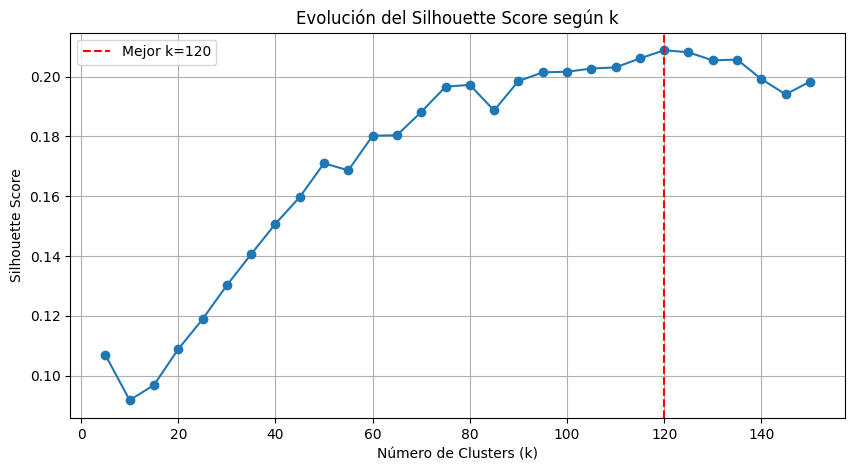

Modelo 'best_kmeans' re-entrenado con k=120 y listo para usar.


In [15]:
# 1. Definimos el rango de k (de 5 en 5 hasta 150)
k_range = range(5, 151, 5)
silhouette_scores = []

print("Entrenando modelos y calculando Silhouette Scores (esto puede tardar unos segundos)...")

# 2. Bucle para probar cada k
for k in k_range:
    # Instanciamos K-Means
    # n_init=10 es el estándar para que el algoritmo pruebe 10 semillas diferentes y se quede con la mejor
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Entrenamos con los datos reducidos por PCA (¡Mucho más rápido!)
    kmeans.fit(X_train_pca)
    
    # Calculamos el score de silueta
    score = silhouette_score(X_train_pca, kmeans.labels_)
    silhouette_scores.append(score)
    
    # (Opcional) Imprimimos progreso cada cierto tiempo
    if k % 25 == 0:
        print(f"Procesado k={k} -> Score: {score:.4f}")

# 3. Identificar el mejor k
best_score = max(silhouette_scores)
# Buscamos el índice del score máximo y lo usamos para encontrar el k correspondiente
best_k = k_range[silhouette_scores.index(best_score)]

print(f"\n--- RESULTADO FINAL ---")
print(f"El k con el mejor Silhouette Score es: {best_k}")
print(f"Valor del score: {best_score:.4f}")

# 4. Gráfica de la evolución (Muy recomendada para entender qué pasa)
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Evolución del Silhouette Score según k')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
plt.legend()
plt.grid(True)
plt.show()

# Guardamos el mejor modelo para usarlo después
best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_kmeans.fit(X_train_pca)
print(f"Modelo 'best_kmeans' re-entrenado con k={best_k} y listo para usar.")


### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

Calculando Inercia para distintos valores de k...


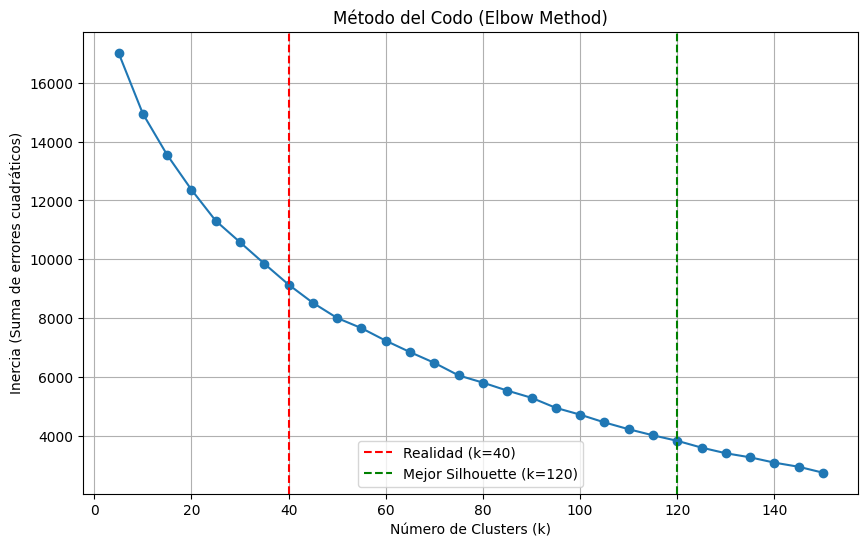

In [16]:
# Usamos el mismo rango de k
k_range = range(5, 151, 5)
inertias = []

print("Calculando Inercia para distintos valores de k...")

for k in k_range:
    # Entrenamos igual que antes (usando los datos PCA)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_pca)
    
    # En lugar de calcular silhouette, guardamos la inercia
    # La inercia es un atributo interno del modelo ya entrenado (.inertia_)
    inertias.append(kmeans.inertia_)

# Graficamos el método del Codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='-')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (Suma de errores cuadráticos)')
plt.grid(True)

# Añadimos una línea vertical en k=40 (el número real de personas) para referencia
plt.axvline(x=40, color='red', linestyle='--', label='Realidad (k=40)')
# Añadimos una línea en k=120 (tu mejor resultado de Silhouette)
plt.axvline(x=120, color='green', linestyle='--', label='Mejor Silhouette (k=120)')

plt.legend()
plt.show()

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

In [17]:
# 1. Fijamos el k ganador
best_k = 120

# 2. Instanciamos el modelo final
# Usamos n_init=10 y random_state=42 para asegurar que el resultado sea reproducible
best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# 3. Entrenamos el modelo (Fit)
# ¡IMPORTANTE! Recuerda seguir usando los datos reducidos (X_train_pca)
print(f"Entrenando el modelo definitivo con k={best_k}...")
best_model.fit(X_train_pca)

print("¡Modelo entrenado y almacenado en la variable 'best_model'!")

Entrenando el modelo definitivo con k=120...
¡Modelo entrenado y almacenado en la variable 'best_model'!


### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?

Visualizando los primeros 10 clusters del modelo (k=120)...
Nota: Los títulos de las imágenes indican la persona REAL (target).

--- CLUSTER 0 ---


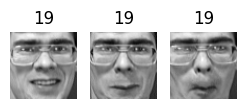


--- CLUSTER 1 ---


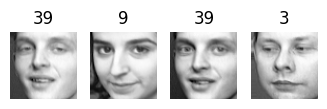


--- CLUSTER 2 ---


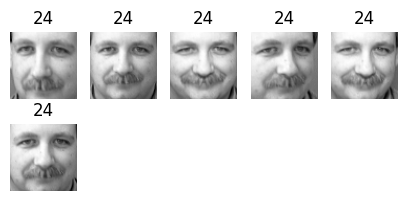


--- CLUSTER 3 ---


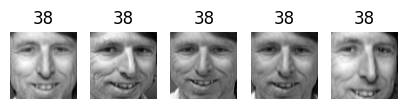


--- CLUSTER 4 ---


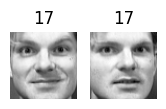


--- CLUSTER 5 ---


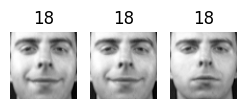


--- CLUSTER 6 ---


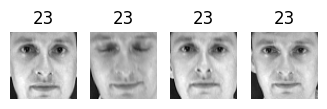


--- CLUSTER 7 ---


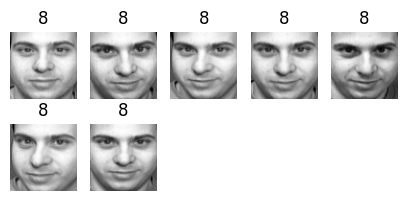


--- CLUSTER 8 ---


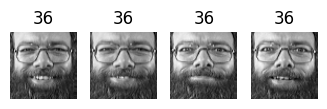


--- CLUSTER 9 ---


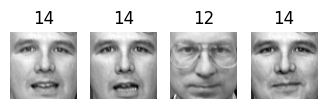

In [18]:
print(f"Visualizando los primeros 10 clusters del modelo (k={best_k})...")
print("Nota: Los títulos de las imágenes indican la persona REAL (target).")

# Recorremos los clusters del 0 al 9
for cluster_id in range(10):
    print(f"\n--- CLUSTER {cluster_id} ---")
    
    # 1. Encontrar qué imágenes pertenecen a este cluster
    # best_model.labels_ es un array del mismo tamaño que X_train
    # Creamos una máscara booleana: True donde la imagen pertenece al cluster actual
    mask = (best_model.labels_ == cluster_id)
    
    # 2. Seleccionar las imágenes ORIGINALES usando esa máscara
    # Aquí está la "adaptación": Usamos la máscara sobre X_train (píxeles), no X_train_pca
    faces_in_cluster = X_train[mask]
    labels_in_cluster = y_train[mask]
    
    # 3. Comprobamos si el cluster tiene imágenes (podría estar vacío)
    if len(faces_in_cluster) > 0:
        # Llamamos a la función que definimos en el Ejercicio 4.1
        plot_faces(faces_in_cluster, labels_in_cluster)
    else:
        print(f"El cluster {cluster_id} está vacío (cosa rara pero posible).")

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

In [21]:
# 1. Instanciar el clasificador Random Forest
# n_estimators=150: Creamos un "bosque" con 150 árboles de decisión distintos.
# random_state=42: Para que los resultados sean reproducibles.
clf_rf = RandomForestClassifier(n_estimators=150, random_state=42)

print("Entrenando el Random Forest (Supervisado)...")

# 2. Entrenar el modelo (Fit)
# Usamos X_train_pca (las features reducidas) y y_train (las etiquetas reales)
clf_rf.fit(X_train_pca, y_train)

# 3. Evaluar en el conjunto de Validación
# Primero predecimos sobre los datos de validación
print("Evaluando en el conjunto de validación...")
score_val = clf_rf.score(X_val_pca, y_val)

print(f"\n--- RESULTADO CLASIFICACIÓN SUPERVISADA ---")
print(f"Accuracy (Precisión) en Validación: {score_val:.4f} ({score_val*100:.2f}%)")

Entrenando el Random Forest (Supervisado)...
Evaluando en el conjunto de validación...

--- RESULTADO CLASIFICACIÓN SUPERVISADA ---
Accuracy (Precisión) en Validación: 0.9250 (92.50%)


### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

In [22]:
# 1. Transformar los datos usando K-Means
# El método .transform() devuelve la distancia de cada instancia a cada uno de los 120 centroides.
# Por tanto, pasamos de ~200 features (PCA) a exactamente 120 features (Cluster Distances).
print("Generando nuevas features basadas en distancias a los centroides...")

X_train_kmeans = best_model.transform(X_train_pca)
X_val_kmeans = best_model.transform(X_val_pca)
X_test_kmeans = best_model.transform(X_test_pca)

# Verificamos la nueva forma
print(f"Nueva dimensión de X_train: {X_train_kmeans.shape} (Debe ser n_muestras x 120)")

# 2. Entrenar el Random Forest con estas nuevas features
clf_rf_k = RandomForestClassifier(n_estimators=150, random_state=42)

print("\nEntrenando Random Forest sobre las distancias K-Means...")
clf_rf_k.fit(X_train_kmeans, y_train)

# 3. Evaluar en el conjunto de Validación
score_val_k = clf_rf_k.score(X_val_kmeans, y_val)

print(f"\n--- RESULTADO CLASIFICACIÓN CON K-MEANS FEATURES ---")
print(f"Accuracy en Validación: {score_val_k:.4f} ({score_val_k*100:.2f}%)")

# (Opcional) Comparativa rápida con el ejercicio anterior
print(f"Diferencia con RF estándar: {(score_val_k - score_val)*100:.2f}%")

Generando nuevas features basadas en distancias a los centroides...
Nueva dimensión de X_train: (320, 120) (Debe ser n_muestras x 120)

Entrenando Random Forest sobre las distancias K-Means...

--- RESULTADO CLASIFICACIÓN CON K-MEANS FEATURES ---
Accuracy en Validación: 0.8000 (80.00%)
Diferencia con RF estándar: -12.50%


### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus distancias a los centroides sean las features de un clasificador RandomForest y que permita al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos de Accuracy)

Buscando el k óptimo para clasificación (esto tardará un poco)...
k=20 -> Accuracy: 0.6750
k=40 -> Accuracy: 0.8250
k=60 -> Accuracy: 0.7500
k=80 -> Accuracy: 0.7750
k=100 -> Accuracy: 0.7500
k=120 -> Accuracy: 0.8000
k=140 -> Accuracy: 0.7750
k=160 -> Accuracy: 0.7500
k=180 -> Accuracy: 0.7500
k=200 -> Accuracy: 0.8250
k=220 -> Accuracy: 0.7750
k=240 -> Accuracy: 0.8000
k=260 -> Accuracy: 0.7750
k=280 -> Accuracy: 0.7750
k=300 -> Accuracy: 0.8250

--- MEJOR RESULTADO ---
El mejor k para clasificar es: 40
Accuracy alcanzado: 0.8250 (82.50%)


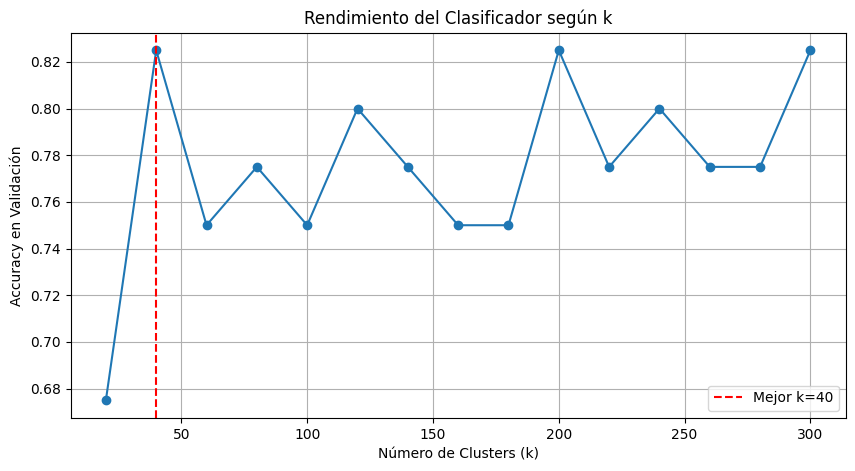

In [23]:
# 1. Definimos el rango de búsqueda
# Probaremos desde 20 hasta 300 clusters, saltando de 20 en 20.
# (Recuerda que tenemos 320 imágenes en total en el train)
k_values = range(20, 301, 20)
accuracies = []

best_k_clf = 0
best_acc = 0

print("Buscando el k óptimo para clasificación (esto tardará un poco)...")

# 2. Bucle de optimización
for k in k_values:
    # A. Pipeline: K-Means como extractor de características
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_pca)
    
    # B. Transformamos los datos a distancias
    X_train_reduced = kmeans.transform(X_train_pca)
    X_val_reduced = kmeans.transform(X_val_pca)
    
    # C. Entrenamos el Clasificador
    rf = RandomForestClassifier(n_estimators=150, random_state=42)
    rf.fit(X_train_reduced, y_train)
    
    # D. Evaluamos
    score = rf.score(X_val_reduced, y_val)
    accuracies.append(score)
    
    print(f"k={k} -> Accuracy: {score:.4f}")
    
    # Guardamos el mejor resultado
    if score > best_acc:
        best_acc = score
        best_k_clf = k

print(f"\n--- MEJOR RESULTADO ---")
print(f"El mejor k para clasificar es: {best_k_clf}")
print(f"Accuracy alcanzado: {best_acc:.4f} ({best_acc*100:.2f}%)")

# 3. Gráfica de la evolución
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Accuracy en Validación')
plt.title('Rendimiento del Clasificador según k')
plt.axvline(x=best_k_clf, color='r', linestyle='--', label=f'Mejor k={best_k_clf}')
plt.grid(True)
plt.legend()
plt.show()